In [ ]:
import matplotlib.pyplot as plt
import joblib as jlb
import seaborn as sns
import pandas as pd
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

from collections import Counter

from Algorithm import CLARANS
from pyclustering.utils import timedcall
from Dataprepare.data_processing import D
from utils import clarans_fast_build,clarans_silhouette_analysis,clarans_davies_bouldin_analysis,clarans_Inertia_analysis

In [ ]:
features=['Income','Age','Total_Spend']
data=D[features].copy()
print(data.shape)
print(data.head(1))

     Income       Age  Total_Spend
0  0.316484  1.015715     1.205616


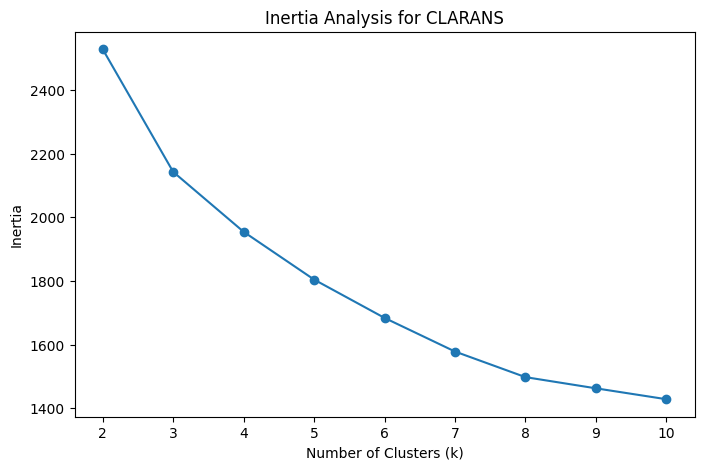

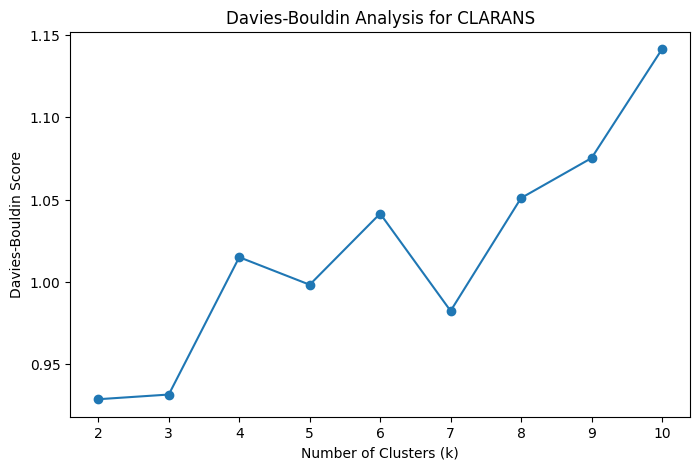

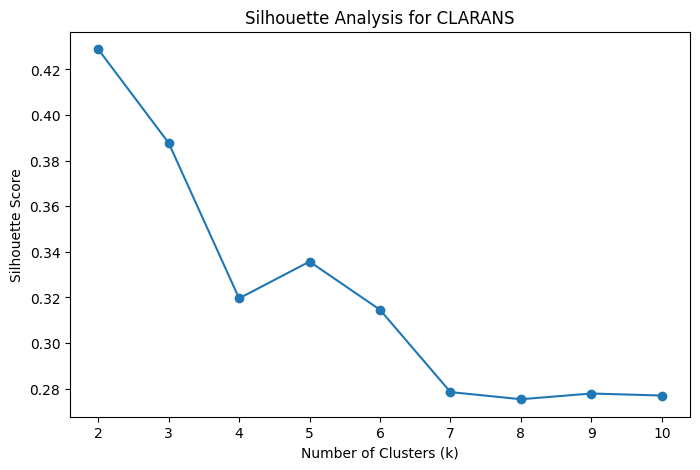

In [5]:
clarans_Inertia_analysis(data,[2,3,4,5,6,7,8,9,10],num_local=10,max_neighbors=100)
clarans_davies_bouldin_analysis(data,[2,3,4,5,6,7,8,9,10],num_local=10,max_neighbors=100)
clarans_silhouette_analysis(data,[2,3,4,5,6,7,8,9,10],num_local=10,max_neighbors=100)

In [6]:
#xay dung model clarans
k = 3
n_local=5
max_nei=100
Clarans_model = CLARANS(data, k, n_local, max_nei)
(ticks, result) = timedcall(Clarans_model.fit)
print(f"Time taken: {ticks:.4f} seconds")

Time taken: 0.0572 seconds


In [7]:
#lấy cluster và medoids
labels=Clarans_model.get_labels()
medoids = Clarans_model.get_medoids()

print("Labels:", labels)
print("Medoids:", medoids)

Labels: [2 1 2 ... 0 2 2]
Medoids: [[ 0.45223475 -0.52211561  0.78514381]
 [-1.03262237 -0.4366806  -1.21044191]
 [ 0.74121456  0.93027955  0.5283329 ]]


In [8]:
#gắn nhãn cluster đã có vào df
data['cluster'] = labels
print(data.head(5))
print('\nKích thước clusters:', Counter(labels))
print('\n2 clusters lớn nhất:', Counter(labels).most_common(2))

     Income       Age  Total_Spend  cluster
0  0.316484  1.015715     1.205616        2
1 -0.256135  1.272020    -1.564059        1
2  0.970719  0.332234     0.704827        2
3 -1.212506 -1.291031    -1.115654        1
4  0.324010 -1.034726     0.289678        0

Kích thước clusters: Counter({np.int64(1): 864, np.int64(2): 700, np.int64(0): 665})

2 clusters lớn nhất: [(np.int64(1), 864), (np.int64(2), 700)]


In [10]:
#luu model
jlb.dump(Clarans_model,'../customer_clustering/Output/clarans.mdl')

['../customer_clustering/Output/clarans.mdl']

In [11]:
#load model
Loaded_Clarans_model = jlb.load('../customer_clustering/Output/clarans.mdl')

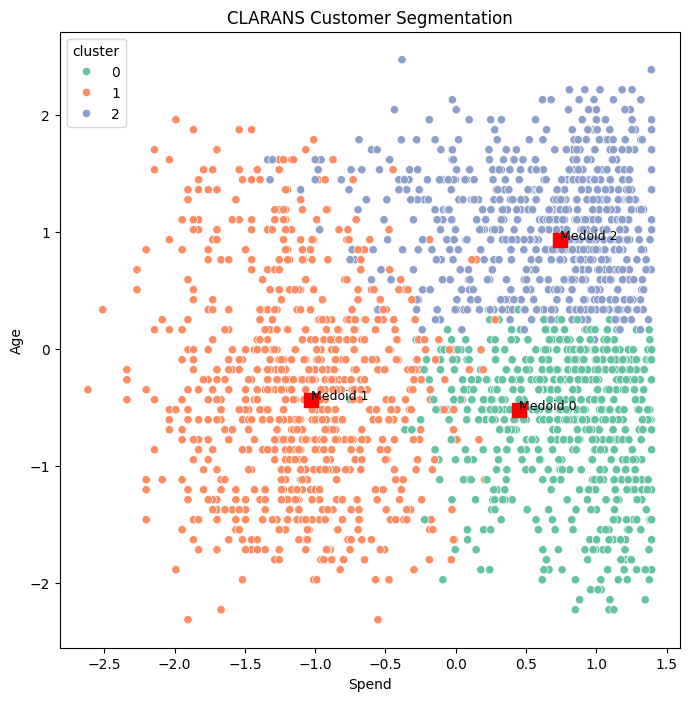

In [13]:
#hien thi model

plt.figure(figsize=(8,8))

sns.scatterplot(x=data['Total_Spend'],
            y=data['Age'],
            hue=data['cluster'], palette="Set2")

for i, medoid in enumerate(medoids):
    plt.text(medoid[0], medoid[1], f'Medoid {i}', fontsize=9)
plt.scatter(medoids[:, 0],
            medoids[:, 1],
            marker='s',
            s=100,color='red'
            )

plt.xlabel("Spend")
plt.ylabel("Age")
plt.title("CLARANS Customer Segmentation")

plt.show()

In [14]:
pca=PCA(n_components=2)
pca.fit(data)
PCA_ds=pd.DataFrame(pca.transform(data),columns=(['col1','col2']))
print(PCA_ds.describe())

               col1          col2
count  2.229000e+03  2.229000e+03
mean  -7.172369e-18  1.338842e-16
std    1.388366e+00  1.138115e+00
min   -3.383711e+00 -3.001951e+00
25%   -1.236205e+00 -9.250243e-01
50%    1.734924e-01  1.912575e-01
75%    1.143311e+00  9.214726e-01
max    3.177491e+00  2.492348e+00


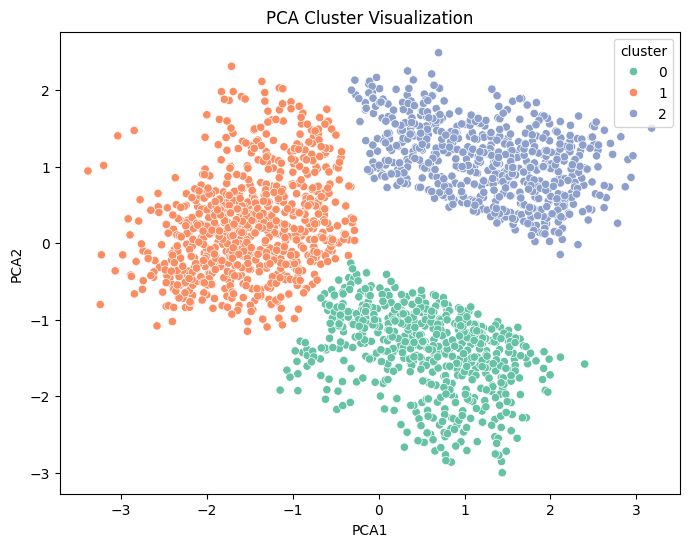

In [18]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=PCA_ds['col1'],
    y=PCA_ds['col2'],
    hue=data['cluster'],
    palette='Set2'
)

plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.title('PCA Cluster Visualization')
plt.show()

Silhouette Score: 0.2312


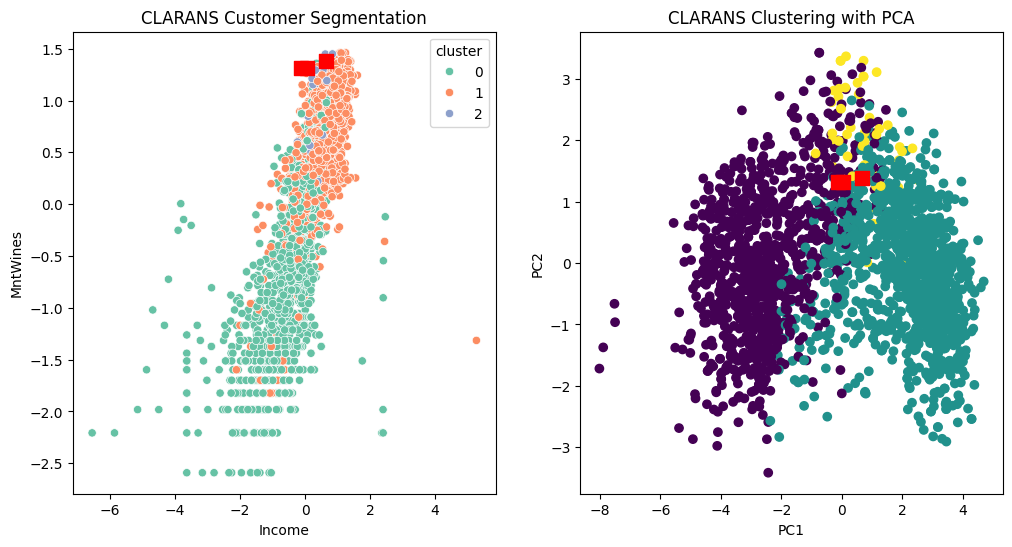

In [7]:
k = 3
n_local=5
max_nei=5
features = [
'Income',
'Age',
'MntWines',
'MntFruits',
'MntMeatProducts',
'MntFishProducts',
'MntSweetProducts',
'MntGoldProds']
datafast=D[features].copy()
# clarans_silhouette_analysis(datafast,[2,3,4,5,6,7,8],num_local=5,max_neighbors=5)
clarans_fast_build(datafast,k,n_local,max_nei,'Income','MntWines',data_pca)

In [ ]:
k = 3
n_local=5
max_nei=5
features = [
'Income',
'Age',
'MntWines',
'MntFruits',
'MntMeatProducts',
'MntFishProducts',
'MntSweetProducts',
'MntGoldProds']
datafast=D[features].copy()
# clarans_silhouette_analysis(datafast,[2,3,4,5,6,7,8],num_local=5,max_neighbors=5)
clarans_fast_build(datafast,k,n_local,max_nei,'Income','MntWines',data_pca)